#### Uyenmy Nguyen
#### Research Question: Which tree type would cover best in a specific wilderness according to its characteristics?

## 1. Load the Dataset----------------------------------------------------------

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')  # suppress non-critical warnings for cleaner output

In [2]:
import kagglehub

# Download the latest version of Forest Cover Type dataset from Kaggle
path = kagglehub.dataset_download("uciml/forest-cover-type-dataset")
print("Path to dataset files:", path)

100%|██████████| 11.2M/11.2M [00:02<00:00, 4.66MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/uciml/forest-cover-type-dataset/versions/1


In [3]:
# Load the dataset with some headlines only
fct = pd.read_csv(path + "/covtype.csv")
fct.head(10)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
5,2579,132,6,300,-15,67,230,237,140,6031,...,0,0,0,0,0,0,0,0,0,2
6,2606,45,7,270,5,633,222,225,138,6256,...,0,0,0,0,0,0,0,0,0,5
7,2605,49,4,234,7,573,222,230,144,6228,...,0,0,0,0,0,0,0,0,0,5
8,2617,45,9,240,56,666,223,221,133,6244,...,0,0,0,0,0,0,0,0,0,5
9,2612,59,10,247,11,636,228,219,124,6230,...,0,0,0,0,0,0,0,0,0,5


## 2. Exploratory Data Analysis (EDA)-------------------------------------------

In [4]:
# Check the overall rows, columns of the dataset
print("Dataset shape:", fct.shape)

# List all column names to understand available features
print("\nColumn names:")
print(fct.columns.tolist())

# Check data types and non-null counts for each column
fct.info()

Dataset shape: (581012, 55)

Column names:
['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Cover_Type']
<class 'pandas.core.frame.DataFrame'>
RangeI

In [5]:
# Check for missing values in each column
print('Missing Values per Column:')
print(fct.isnull().sum())

# Check for duplicate rows
print('\nDuplicate rows:', fct.duplicated().sum())

Missing Values per Column:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11  

In [6]:
# Generate descriptive statistics (mean, std, min, max, quartiles)
# for all numeric columns to understand data distribution
fct.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


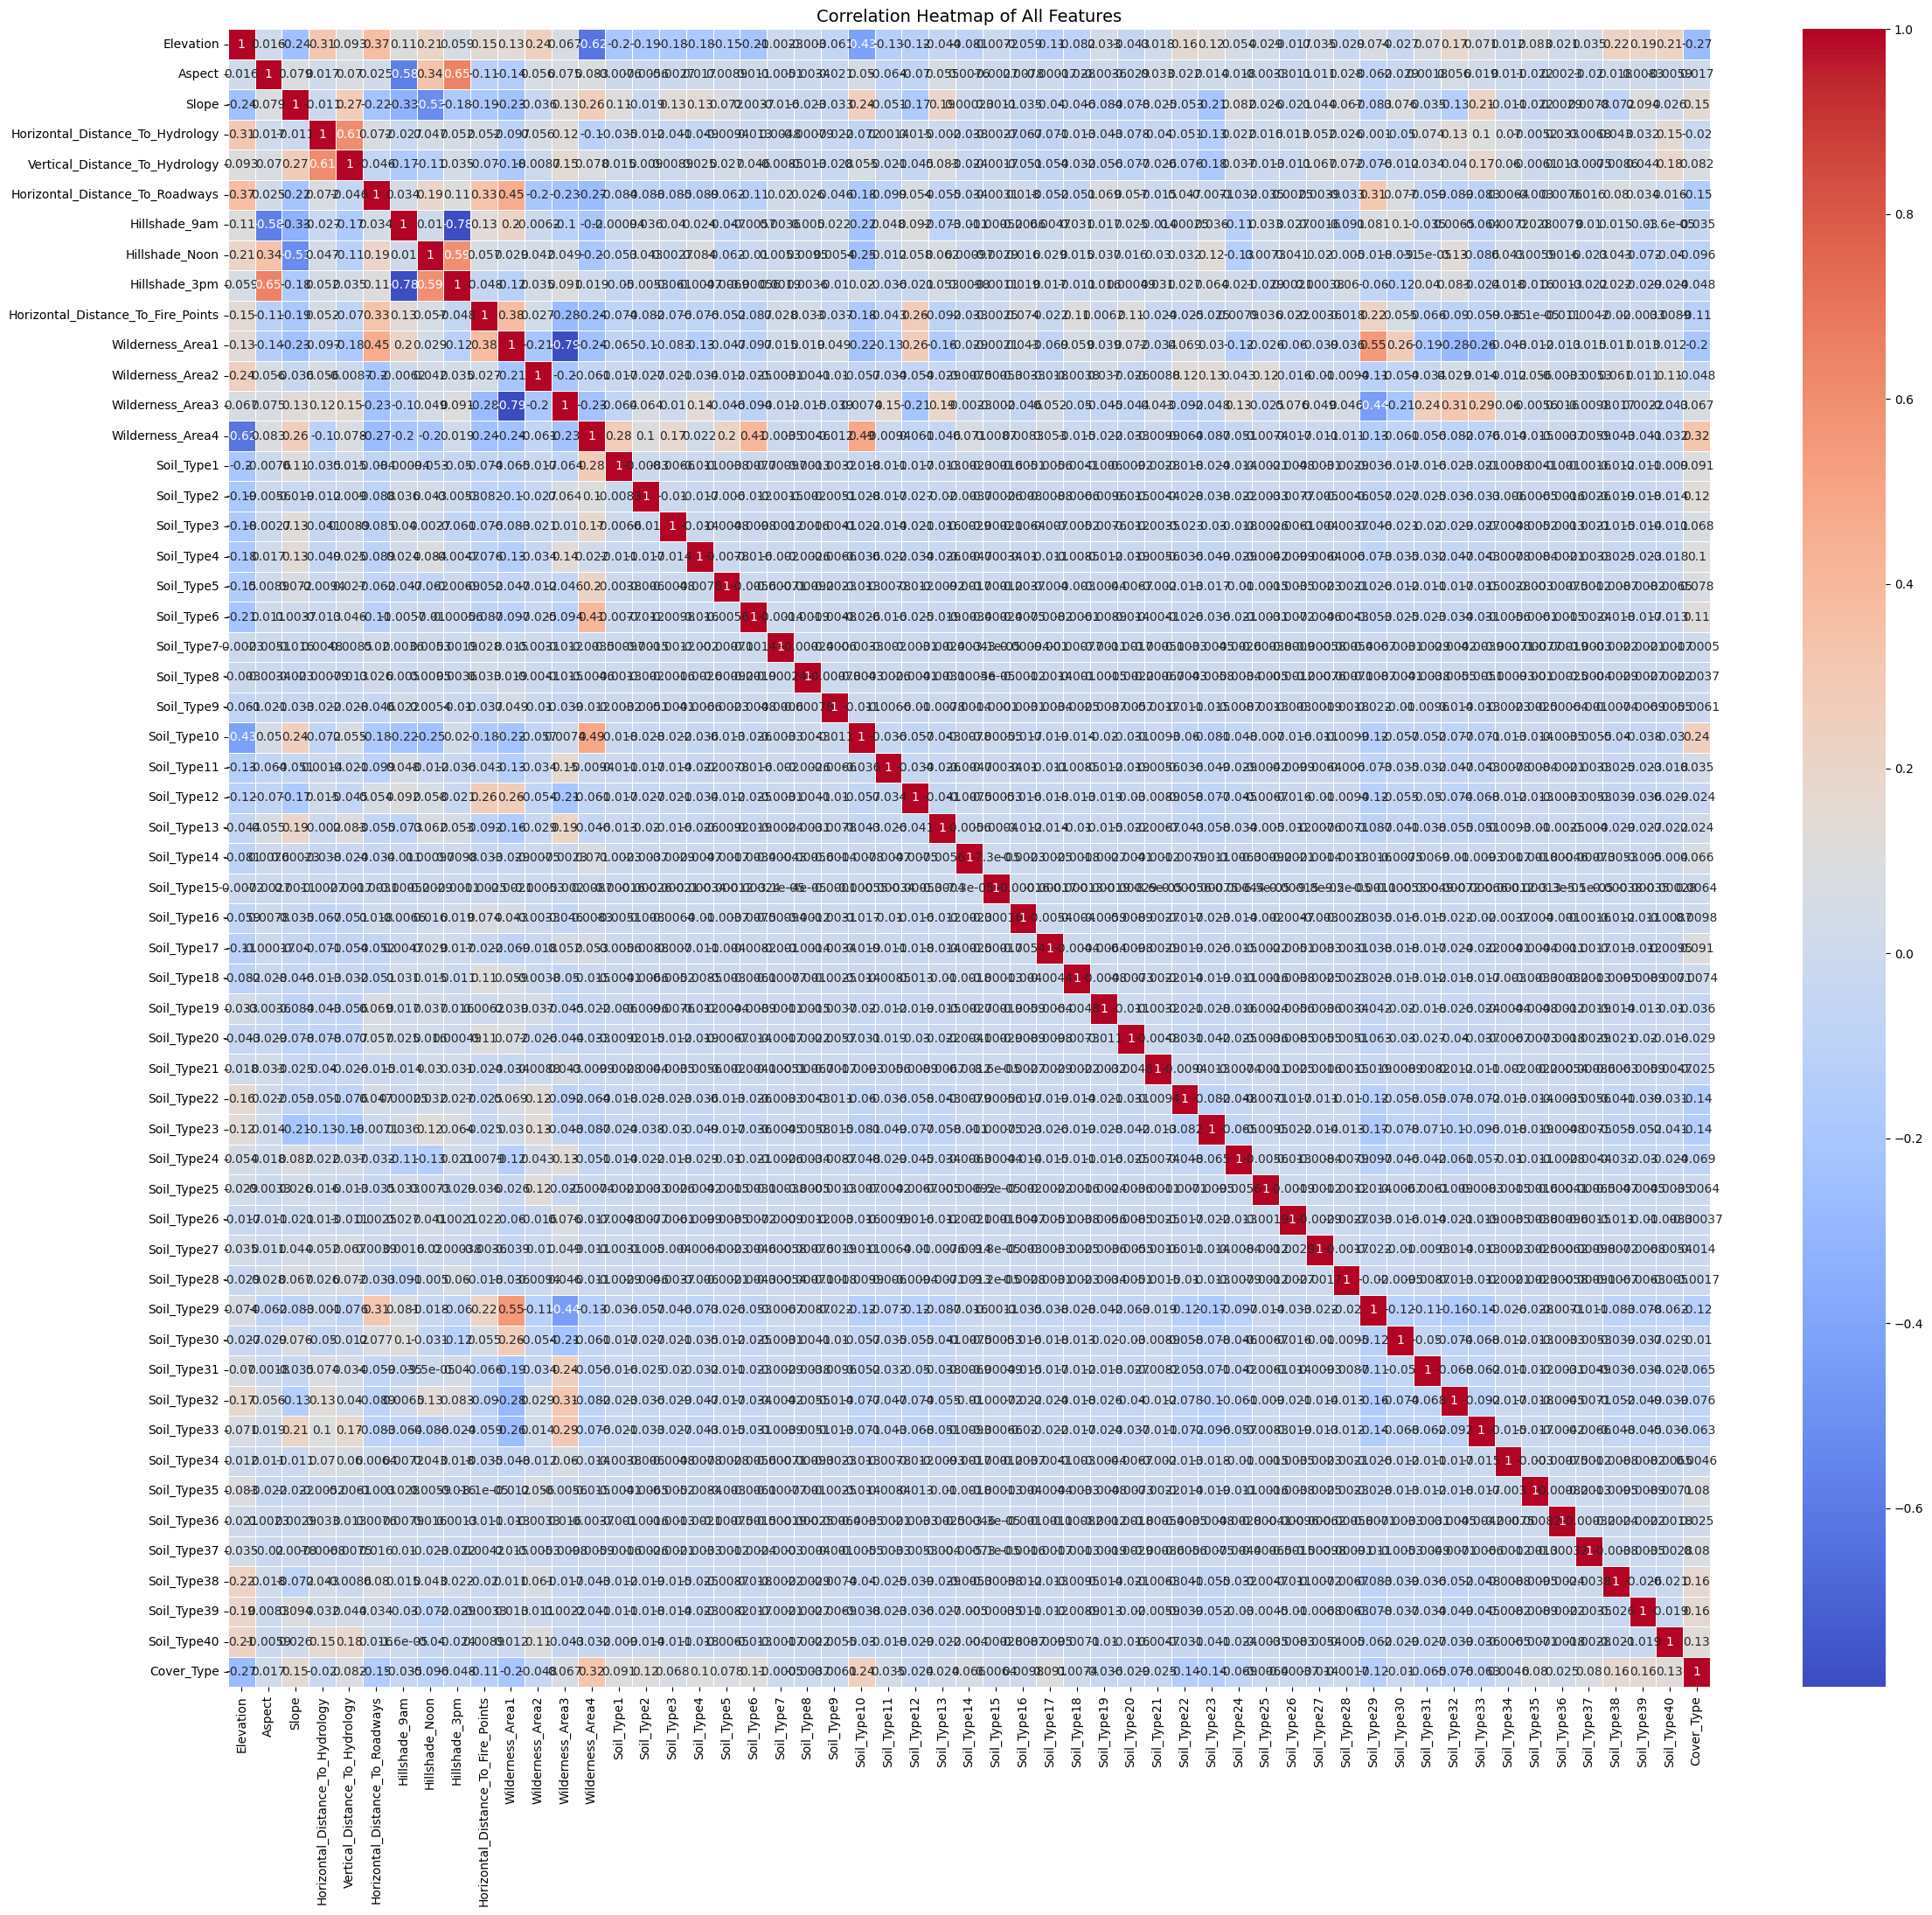

In [7]:
# Correlation Heatmap — reveals linear relationships between all numeric features
# High correlations may indicate redundant features or multicollinearity
corr_matrix = fct.corr(numeric_only=True)
plt.figure(figsize=(24, 22))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=14)
plt.tight_layout()
plt.show()

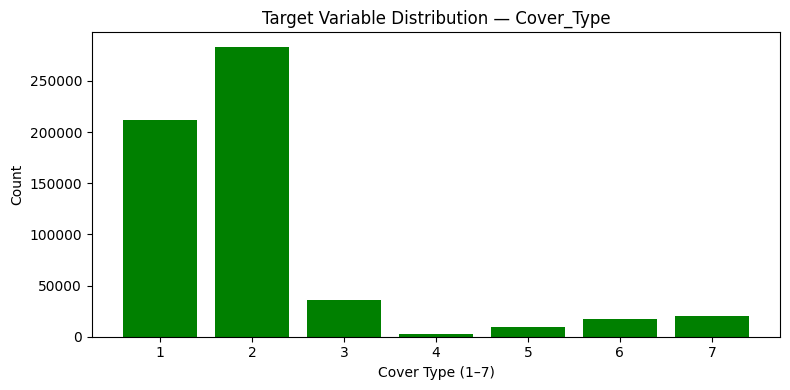

Class counts:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


In [8]:
# Visualize the distribution of the target variable (Cover_Type)
# This helps identify class imbalance before applying any model
target_var = fct['Cover_Type'].dropna()
plt.figure(figsize=(8, 4))
plt.bar(target_var.value_counts().sort_index().index,
        target_var.value_counts().sort_index().values, color='green')
plt.title('Target Variable Distribution \u2014 Cover_Type')
plt.xlabel('Cover Type (1\u20137)')
plt.ylabel('Count')
plt.xticks(range(1, 8))
plt.tight_layout()
plt.show()

# Print exact counts per class
print("Class counts:")
print(fct['Cover_Type'].value_counts().sort_index())

Observation: There is extreme class imbalance, classes 1 and 2 dominate while classes 3 and 7 are minorities.

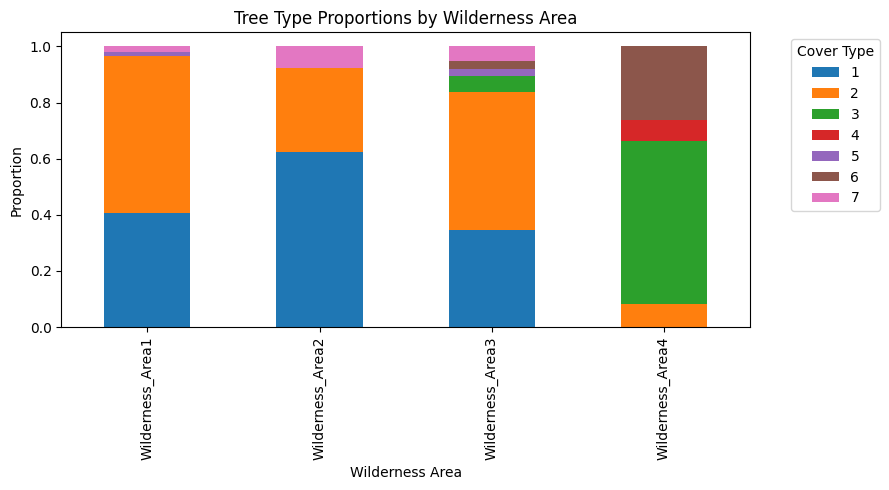

In [9]:
# Visualize the proportion of each tree type within each Wilderness Area
# This helps answer the research question: which tree covers which area most?
wilderness_cols = ["Wilderness_Area1", "Wilderness_Area2", "Wilderness_Area3", "Wilderness_Area4"]

# Convert one-hot encoded wilderness columns into a single categorical column
fct["Wilderness_Area"] = fct[wilderness_cols].idxmax(axis=1)

# Create a cross-tabulation normalized by row (proportion within each area)
ctab = pd.crosstab(fct["Wilderness_Area"], fct["Cover_Type"], normalize="index")
ctab.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("Tree Type Proportions by Wilderness Area")
plt.xlabel("Wilderness Area")
plt.ylabel("Proportion")
plt.legend(title="Cover Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3. Train Validation Test-----------------------------------------------------

In [10]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Drop any derived string columns that were added during EDA
fct_cleaned = fct.dropna(subset=['Cover_Type'])
cols_to_drop = ['Wilderness_Area', 'Soil_Type']
fct_cleaned = fct_cleaned.drop(
    columns=[c for c in cols_to_drop if c in fct_cleaned.columns]
)

# Separate features (X) and target variable (y)
X = fct_cleaned.drop('Cover_Type', axis=1)
y = fct_cleaned['Cover_Type']   # Labels 1\u20137 (original)

# First split - 80% of train+val, 20% test of stratify ensures class balance is preserved
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
# Second split - 75% of 80% = 60% train, 25% of 80% = 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, stratify=y_train_val, random_state=42
)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Train : (348606, 54)
Val   : (116203, 54)
Test  : (116203, 54)


## 4. Preprocessing-------------------------------------------------------------

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline

# All features are numeric, no categorical encoding needed
numeric_features = list(X_train.columns)

# Build numeric transformer by imputing missing values then scale to unit variance
# Median imputation is robust to outliers compared to mean imputation
numeric_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())  # standardize so all features are on the same scale
])

# Wrap in ColumnTransformer to apply numeric_transformer to all numeric columns
preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)],
    remainder="drop"
)

# Cross-validation setup using StratifiedKFold preserves class proportions in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'f1_macro'   # choose macro F1 as the best metric for imbalanced multiclass problems
RANDOM_STATE = 42

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


## 5. Helper Functions----------------------------------------------------------

In [12]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report, confusion_matrix
)

def evaluate(name, model, X_eval, y_eval, offset=0):
    """
    Evaluate a fitted model and print all key metrics.
    offset=1 is used for XGBoost/LightGBM to convert 0-indexed predictions back to 1-7.
    """
    y_pred = model.predict(X_eval)
    if offset:
        y_pred = y_pred + offset  # convert 0-6 back to 1-7 for XGB/LGBM

    acc  = accuracy_score(y_eval, y_pred)
    bacc = balanced_accuracy_score(y_eval, y_pred)  # accounts for class imbalance
    f1   = f1_score(y_eval, y_pred, average='macro')  # unweighted avg across all classes

    print(f'\n=== {name} ===')
    print(classification_report(y_eval, y_pred, digits=3))
    print(f'Accuracy         : {acc:.4f}')
    print(f'Balanced Accuracy: {bacc:.4f}')
    print(f'F1 Macro         : {f1:.4f}')

    # Per class recall highlights how well the model handles minority classes
    from sklearn.metrics import recall_score
    per_class_recall = recall_score(y_eval, y_pred, average=None, labels=sorted(y_eval.unique()))
    labels = sorted(y_eval.unique())
    print('\nPer-Class Recall:')
    for lbl, rec in zip(labels, per_class_recall):
        print(f'  Class {lbl}: {rec:.4f}')

    print('\nConfusion Matrix:')
    print(confusion_matrix(y_eval, y_pred))
    return {'Accuracy': acc, 'Balanced_Acc': bacc, 'F1_Macro': f1}


def plot_cm(y_true, y_pred, title):
    """Plot a color-coded confusion matrix heatmap for easy visual inspection."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y_true.unique()),
                yticklabels=sorted(y_true.unique()))
    plt.title(f'Confusion Matrix Heatmap \u2014 {title}', fontsize=12)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()


# Initialize results list to collect metrics from all models for final comparison
results_table = []
print("Helper functions defined.")

Helper functions defined.


## 6. Baseline Models before Class Imbalance Handling---------------------------

LOGISTIC REGRESSION


=== Logistic Regression — VALIDATION ===
              precision    recall  f1-score   support

           1      0.711     0.693     0.702     42368
           2      0.746     0.802     0.773     56660
           3      0.685     0.810     0.742      7151
           4      0.614     0.443     0.514       549
           5      0.258     0.008     0.016      1899
           6      0.491     0.270     0.348      3474
           7      0.735     0.567     0.640      4102

    accuracy                          0.724    116203
   macro avg      0.606     0.513     0.534    116203
weighted avg      0.713     0.724     0.714    116203

Accuracy         : 0.7238
Balanced Accuracy: 0.5132
F1 Macro         : 0.5336

Per-Class Recall:
  Class 1: 0.6925
  Class 2: 0.8023
  Class 3: 0.8101
  Class 4: 0.4426
  Class 5: 0.0084
  Class 6: 0.2697
  Class 7: 0.5666

Confusion Matrix:
[[29340 12192     9     0     0    18   809]
 [10184 45460   628     3    32   324    29]
 [    0   634  5793   138    

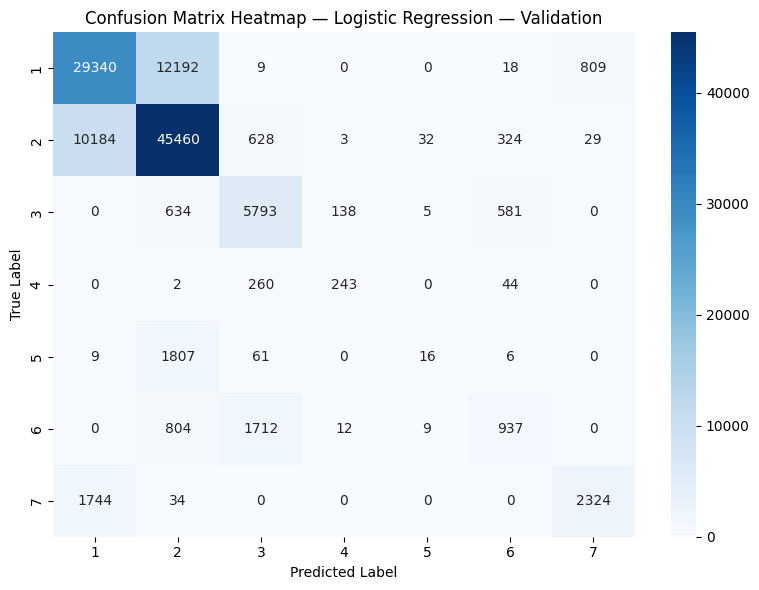

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline

# Logistic Regression as a simple linear baseline
# using max_iter=1000 ensures convergence on this large dataset
lr_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
])
lr_pipe.fit(X_train, y_train)

# Evaluate on validation set and store results
lr_metrics = evaluate('Logistic Regression \u2014 VALIDATION', lr_pipe, X_val, y_val)
results_table.append({'Model': 'Logistic Regression (Baseline)', **lr_metrics})
plot_cm(y_val, lr_pipe.predict(X_val), 'Logistic Regression \u2014 Validation')

DECISION TREE

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params (DT): {'dtclf__max_depth': None, 'dtclf__min_samples_split': 2}

=== Decision Tree — VALIDATION ===
              precision    recall  f1-score   support

           1      0.931     0.929     0.930     42368
           2      0.941     0.941     0.941     56660
           3      0.910     0.921     0.915      7151
           4      0.818     0.827     0.822       549
           5      0.791     0.821     0.806      1899
           6      0.860     0.845     0.852      3474
           7      0.942     0.947     0.944      4102

    accuracy                          0.930    116203
   macro avg      0.885     0.890     0.887    116203
weighted avg      0.930     0.930     0.930    116203

Accuracy         : 0.9302
Balanced Accuracy: 0.8900
F1 Macro         : 0.8873

Per-Class Recall:
  Class 1: 0.9292
  Class 2: 0.9408
  Class 3: 0.9206
  Class 4: 0.8270
  Class 5: 0.8210
  Class 6: 0.8448
  Class 7: 0.9469

Confusi

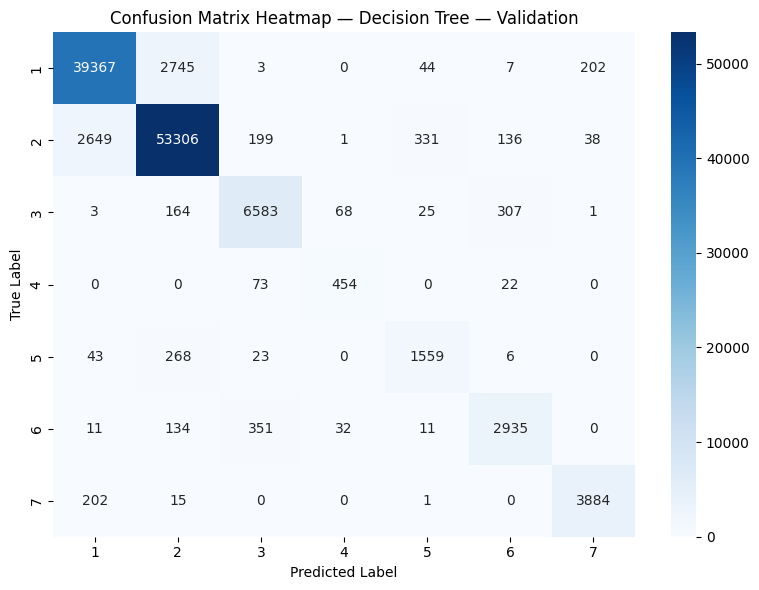

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# create pipeline for decision tree with GridSearchCV to find optimal depth and split parameters
dt_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('dtclf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt_grid = GridSearchCV(
    dt_pipe,
    param_grid={
        'dtclf__max_depth': [None, 10, 20],          # None - fully grown tree
        'dtclf__min_samples_split': [2, 5, 10]       # minimum samples to allow a split
    },
    scoring=SCORING, cv=cv, n_jobs=-1, verbose=1
)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_

print('Best params (DT):', dt_grid.best_params_)
dt_metrics = evaluate('Decision Tree \u2014 VALIDATION', dt_best, X_val, y_val)
results_table.append({'Model': 'Decision Tree (Baseline)', **dt_metrics})
plot_cm(y_val, dt_best.predict(X_val), 'Decision Tree \u2014 Validation')

RANDOM FOREST

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params (RF): {'clf__max_depth': None, 'clf__n_estimators': 500}

=== Random Forest — VALIDATION ===
              precision    recall  f1-score   support

           1      0.960     0.934     0.947     42368
           2      0.943     0.970     0.956     56660
           3      0.934     0.958     0.946      7151
           4      0.908     0.847     0.877       549
           5      0.921     0.756     0.830      1899
           6      0.922     0.888     0.905      3474
           7      0.974     0.940     0.957      4102

    accuracy                          0.948    116203
   macro avg      0.937     0.899     0.917    116203
weighted avg      0.948     0.948     0.948    116203

Accuracy         : 0.9483
Balanced Accuracy: 0.8989
F1 Macro         : 0.9166

Per-Class Recall:
  Class 1: 0.9335
  Class 2: 0.9699
  Class 3: 0.9576
  Class 4: 0.8470
  Class 5: 0.7557
  Class 6: 0.8883
  Class 7: 0.9400

Confusion Matr

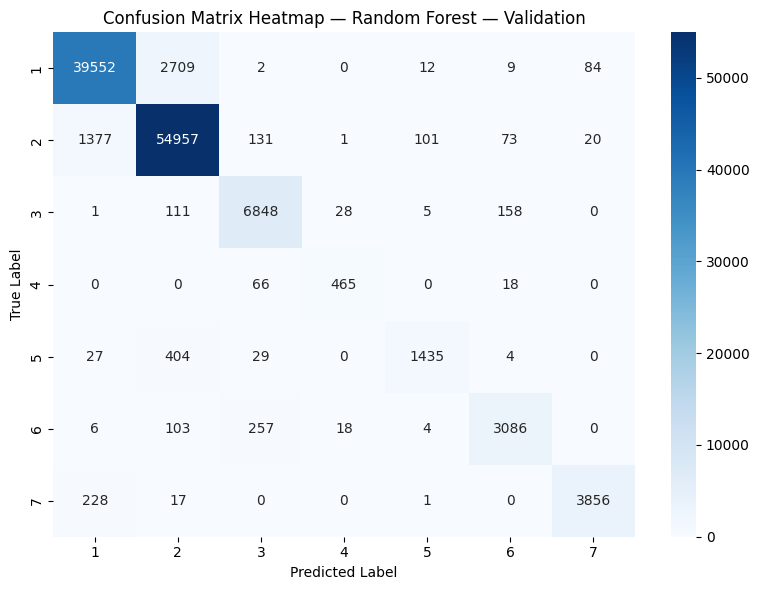

In [15]:
from sklearn.ensemble import RandomForestClassifier

# create pipeline for random forest (an ensemble of decision trees — more robust and less prone to overfitting)
rf_pipe = SkPipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid={
        'clf__n_estimators': [300, 500],    # more trees for more stable predictions
        'clf__max_depth': [None, 10, 20]    # control tree complexity
    },
    scoring=SCORING, cv=cv, n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

print('Best params (RF):', rf_grid.best_params_)
rf_metrics = evaluate('Random Forest \u2014 VALIDATION', rf_best, X_val, y_val)
results_table.append({'Model': 'Random Forest (Baseline)', **rf_metrics})
plot_cm(y_val, rf_best.predict(X_val), 'Random Forest \u2014 Validation')

XGBOOST

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params (XGB): {'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 500}

=== XGBoost — VALIDATION ===
              precision    recall  f1-score   support

           0      0.000     0.000     0.000     42368
           1      0.105     0.076     0.088     56660
           2      0.003     0.026     0.006      7151
           3      0.009     0.117     0.017       549
           4      0.000     0.000     0.000      1899
           5      0.001     0.001     0.001      3474
           6      0.000     0.000     0.000      4102
           7      0.000     0.000     0.000         0

    accuracy                          0.039    116203
   macro avg      0.015     0.027     0.014    116203
weighted avg      0.051     0.039     0.044    116203

Accuracy         : 0.0393
Balanced Accuracy: 0.0313
F1 Macro         : 0.0139

Per-Class Recall:
  Class 0: 0.0000
  Class 1: 0.0762
  Class 2: 0.0257
  Class 3: 0.1

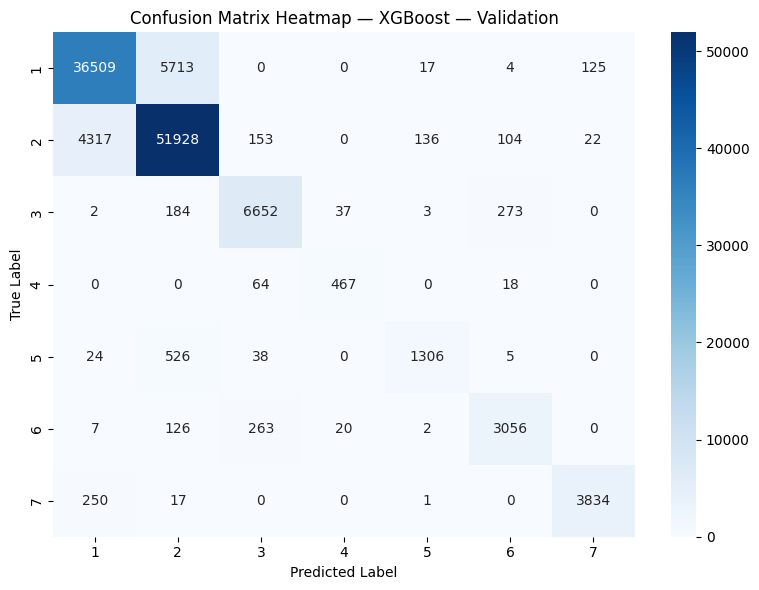

In [16]:
from xgboost import XGBClassifier

# XGBoost requires 0-indexed labels (0-6), so we subtract 1 from y
# Predictions will be converted back to 1-7 during evaluation
y_train_adj = y_train - 1   # 1-7,  0-6
y_val_adj   = y_val   - 1
y_test_adj  = y_test  - 1
num_classes = y.nunique()   # 7 classes total

xgb_pipe = SkPipeline([
    ('prep', preprocess),
    ('clf', XGBClassifier(
        objective='multi:softprob',   # outputs probability per class
        num_class=num_classes,
        eval_metric='mlogloss',
        tree_method='hist',           # histogram-based for faster training
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_grid = GridSearchCV(
    xgb_pipe,
    param_grid={
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [4, 6],
        'clf__learning_rate': [0.05, 0.1]
    },
    scoring=SCORING, cv=cv, n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train, y_train_adj)   # fit with 0-indexed labels
xgb_best = xgb_grid.best_estimator_

print('Best params (XGB):', xgb_grid.best_params_)
# offset=1 adds back 1 so predictions align with original labels 1-7
xgb_metrics = evaluate('XGBoost \u2014 VALIDATION', xgb_best, X_val, y_val_adj, offset=1)
results_table.append({'Model': 'XGBoost (Baseline)', **xgb_metrics})
plot_cm(y_val, xgb_best.predict(X_val) + 1, 'XGBoost \u2014 Validation')

## 7. Class Imbalance Handling--------------------------------------------------

# SMOTE

In [17]:
# Import imbalance-handling libraries
# ImbPipeline is used instead of sklearn Pipeline so SMOTE only runs inside CV folds
# This prevents data leakage from the validation fold into training
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight

print("Imbalance handling libraries imported.")

Imbalance handling libraries imported.


DECISION TREE

In [18]:
# SMOTE w Decision Tree
# SMOTE generates synthetic minority class samples to balance the training set
# Using imblearn Pipeline to ensures SMOTE is applied only inside each CV fold
smote_dt_pipe = ImbPipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),   # applied inside CV folds only
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

smote_dt_params = {
    'smote__k_neighbors': [3, 5],                        # neighbors used to generate synthetic points
    'clf__max_depth': [10, 20, 30, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': [None, 'balanced']
}

# RandomizedSearchCV is faster than GridSearchCV for large parameter spaces
smote_dt_search = RandomizedSearchCV(
    smote_dt_pipe, param_distributions=smote_dt_params,
    n_iter=20, scoring=SCORING, cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
smote_dt_search.fit(X_train, y_train)
smote_dt_best = smote_dt_search.best_estimator_

print('Best params (SMOTE + DT):', smote_dt_search.best_params_)
print(f'Best CV F1 Macro: {smote_dt_search.best_score_:.4f}')
sdt_metrics = evaluate('SMOTE + Decision Tree \u2014 VALIDATION', smote_dt_best, X_val, y_val)
results_table.append({'Model': 'SMOTE + Decision Tree', **sdt_metrics})

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params (SMOTE + DT): {'smote__k_neighbors': 5, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}
Best CV F1 Macro: 0.8808

=== SMOTE + Decision Tree — VALIDATION ===
              precision    recall  f1-score   support

           1      0.921     0.937     0.929     42368
           2      0.950     0.927     0.939     56660
           3      0.916     0.932     0.924      7151
           4      0.838     0.878     0.858       549
           5      0.764     0.858     0.808      1899
           6      0.843     0.872     0.857      3474
           7      0.928     0.957     0.942      4102

    accuracy                          0.929    116203
   macro avg      0.880     0.909     0.894    116203
weighted avg      0.930     0.929     0.929    116203

Accuracy         : 0.9290
Balanced Accuracy: 0.9086
F1 Macro         : 0.8938

RANDOM FOREST

In [20]:
# SMOTE w Random Forest
# Combining SMOTE with Random Forest helps the ensemble learn from balanced classes
smote_rf_pipe = ImbPipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

smote_rf_params = {
    'smote__k_neighbors': [3, 5],
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2']   # controls feature randomness per split
}

# tuning by RandomizedSearchCV and StratifiedKFold (with cross validation)
smote_rf_search = RandomizedSearchCV(
    smote_rf_pipe, param_distributions=smote_rf_params,
    n_iter=20, scoring=SCORING, cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
smote_rf_search.fit(X_train, y_train)
smote_rf_best = smote_rf_search.best_estimator_

print('Best params (SMOTE + RF):', smote_rf_search.best_params_)
print(f'Best CV F1 Macro: {smote_rf_search.best_score_:.4f}')
srf_metrics = evaluate('SMOTE + Random Forest \u2014 VALIDATION', smote_rf_best, X_val, y_val)
results_table.append({'Model': 'SMOTE + Random Forest', **srf_metrics})

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params (SMOTE + RF): {'smote__k_neighbors': 3, 'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Best CV F1 Macro: 0.9209

=== SMOTE + Random Forest — VALIDATION ===
              precision    recall  f1-score   support

           1      0.959     0.941     0.950     42368
           2      0.955     0.959     0.957     56660
           3      0.937     0.958     0.947      7151
           4      0.881     0.907     0.894       549
           5      0.841     0.891     0.865      1899
           6      0.879     0.927     0.902      3474
           7      0.956     0.970     0.963      4102

    accuracy                          0.951    116203
   macro avg      0.916     0.936     0.926    116203
weighted avg      0.951     0.951     0.951    116203

Accuracy         : 0.9507
Balanced Accuracy: 0.9362
F1 Macro         : 0.9256

Per-C

XGBOOST

In [21]:
# SMOTE w XGBoost
# XGBoost still requires 0-indexed labels (y_train_adj)
smote_xgb_pipe = ImbPipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

smote_xgb_params = {
    'smote__k_neighbors': [3, 5],
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [4, 6, 8],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.8, 1.0],          # fraction of samples used per tree
    'clf__colsample_bytree': [0.7, 0.8, 1.0]    # fraction of features used per tree
}

# tuning with RandomizedSearchCV and StratifiedKFold
smote_xgb_search = RandomizedSearchCV(
    smote_xgb_pipe, param_distributions=smote_xgb_params,
    n_iter=20, scoring=SCORING, cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
smote_xgb_search.fit(X_train, y_train_adj)   # 0-indexed for XGBoost
smote_xgb_best = smote_xgb_search.best_estimator_

print('Best params (SMOTE + XGB):', smote_xgb_search.best_params_)
print(f'Best CV F1 Macro: {smote_xgb_search.best_score_:.4f}')
# offset=1 to add 1 back so predictions are 1-7
sxgb_metrics = evaluate('SMOTE + XGBoost \u2014 VALIDATION', smote_xgb_best, X_val, y_val_adj, offset=1)
results_table.append({'Model': 'SMOTE + XGBoost', **sxgb_metrics})

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params (SMOTE + XGB): {'smote__k_neighbors': 3, 'clf__subsample': 0.7, 'clf__n_estimators': 300, 'clf__max_depth': 8, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 1.0}
Best CV F1 Macro: 0.9230

=== SMOTE + XGBoost — VALIDATION ===
              precision    recall  f1-score   support

           0      0.000     0.000     0.000     42368
           1      0.057     0.042     0.048     56660
           2      0.001     0.008     0.002      7151
           3      0.004     0.056     0.008       549
           4      0.000     0.000     0.000      1899
           5      0.001     0.001     0.001      3474
           6      0.000     0.000     0.000      4102
           7      0.000     0.000     0.000         0

    accuracy                          0.021    116203
   macro avg      0.008     0.013     0.007    116203
weighted avg      0.028     0.021     0.024    116203

Accuracy         : 0.0211
Balanced Accuracy:

# BALANCED RANDOM FOREST

In [22]:
# Balanced Random Forest to handles imbalance internally
# At each bootstrap sample, it undersamples the majority class to match minority class size
# No need for SMOTE instead uses sklearn Pipeline (not imblearn)
brf_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', BalancedRandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

brf_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__sampling_strategy': ['auto', 'not majority']  # how to resample
}

# using RandomizedSearchCV for tuning
brf_search = RandomizedSearchCV(
    brf_pipe, param_distributions=brf_params,
    n_iter=20, scoring=SCORING, cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
brf_search.fit(X_train, y_train)
brf_best = brf_search.best_estimator_

print('Best params (BRF):', brf_search.best_params_)
print(f'Best CV F1 Macro: {brf_search.best_score_:.4f}')
brf_metrics = evaluate('Balanced Random Forest \u2014 VALIDATION', brf_best, X_val, y_val)
results_table.append({'Model': 'Balanced Random Forest', **brf_metrics})

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params (BRF): {'clf__sampling_strategy': 'auto', 'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Best CV F1 Macro: 0.7165

=== Balanced Random Forest — VALIDATION ===
              precision    recall  f1-score   support

           1      0.808     0.804     0.806     42368
           2      0.881     0.747     0.809     56660
           3      0.801     0.852     0.826      7151
           4      0.537     0.973     0.692       549
           5      0.316     0.968     0.476      1899
           6      0.573     0.897     0.699      3474
           7      0.649     0.980     0.781      4102

    accuracy                          0.792    116203
   macro avg      0.652     0.889     0.727    116203
weighted avg      0.822     0.792     0.799    116203

Accuracy         : 0.7915
Balanced Accuracy: 0.8887
F1 Macro         : 0.7270

Pe

# COST-SENSITIVE

In [25]:
# Cost-Sensitive Learning (penalizes misclassification of minority classes during training)
# class_weight='balanced' automatically computes weights inversely proportional to class frequency

# Cost-Sensitive w Decision Tree
cs_dt_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])
cs_dt_grid = GridSearchCV(
    cs_dt_pipe,
    param_grid={
        'clf__max_depth': [10, 20, 30, None],
        'clf__min_samples_split': [2, 5, 10],
        'clf__criterion': ['gini', 'entropy']
    },
    scoring=SCORING, cv=cv, n_jobs=-1, verbose=1
)
cs_dt_grid.fit(X_train, y_train)
cs_dt_best = cs_dt_grid.best_estimator_
cs_dt_metrics = evaluate('Cost-Sensitive DT \u2014 VALIDATION', cs_dt_best, X_val, y_val)
results_table.append({'Model': 'Cost-Sensitive Decision Tree', **cs_dt_metrics})

Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== Cost-Sensitive DT — VALIDATION ===
              precision    recall  f1-score   support

           1      0.935     0.930     0.932     42368
           2      0.940     0.945     0.943     56660
           3      0.917     0.914     0.915      7151
           4      0.846     0.851     0.848       549
           5      0.831     0.807     0.819      1899
           6      0.856     0.854     0.855      3474
           7      0.946     0.943     0.945      4102

    accuracy                          0.932    116203
   macro avg      0.896     0.892     0.894    116203
weighted avg      0.932     0.932     0.932    116203

Accuracy         : 0.9322
Balanced Accuracy: 0.8919
F1 Macro         : 0.8938

Per-Class Recall:
  Class 1: 0.9301
  Class 2: 0.9451
  Class 3: 0.9139
  Class 4: 0.8506
  Class 5: 0.8067
  Class 6: 0.8538
  Class 7: 0.9434

Confusion Matrix:
[[39407  2710     7     0    39    13   192]
 [ 2492 53548 

In [26]:
# Cost-Sensitive w Random Forest
cs_rf_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])
cs_rf_search = RandomizedSearchCV(
    cs_rf_pipe,
    param_distributions={
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [10, 20, None],
        'clf__min_samples_split': [2, 5],
        'clf__max_features': ['sqrt', 'log2']
    },
    n_iter=20, scoring=SCORING, cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
cs_rf_search.fit(X_train, y_train)
cs_rf_best = cs_rf_search.best_estimator_
cs_rf_metrics = evaluate('Cost-Sensitive RF \u2014 VALIDATION', cs_rf_best, X_val, y_val)
results_table.append({'Model': 'Cost-Sensitive Random Forest', **cs_rf_metrics})

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Cost-Sensitive RF — VALIDATION ===
              precision    recall  f1-score   support

           1      0.959     0.933     0.946     42368
           2      0.945     0.965     0.955     56660
           3      0.929     0.955     0.942      7151
           4      0.870     0.902     0.886       549
           5      0.894     0.799     0.844      1899
           6      0.892     0.901     0.897      3474
           7      0.967     0.953     0.960      4102

    accuracy                          0.947    116203
   macro avg      0.922     0.915     0.918    116203
weighted avg      0.947     0.947     0.947    116203

Accuracy         : 0.9471
Balanced Accuracy: 0.9153
F1 Macro         : 0.9183

Per-Class Recall:
  Class 1: 0.9325
  Class 2: 0.9647
  Class 3: 0.9553
  Class 4: 0.9016
  Class 5: 0.7994
  Class 6: 0.9007
  Class 7: 0.9532

Confusion Matrix:
[[39510  2706     3     0    26    14   109]
 [ 1477 54658 

In [27]:
# Cost-Sensitive w XGBoost
# XGBoost does not have a native class_weight parameter
# Instead, I compute sample weights manually and pass them during fitting
w_train = compute_sample_weight(class_weight='balanced', y=y_train_adj)
cs_xgb_pipe = SkPipeline([
    ('prep', preprocess),
    ('clf', XGBClassifier(
        objective='multi:softprob', num_class=num_classes,
        eval_metric='mlogloss', tree_method='hist',
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])
cs_xgb_search = RandomizedSearchCV(
    cs_xgb_pipe,
    param_distributions={
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [4, 6, 8],
        'clf__learning_rate': [0.05, 0.1, 0.2]
    },
    n_iter=20, scoring=SCORING, cv=cv,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
try:
    cs_xgb_search.fit(X_train, y_train_adj, clf__sample_weight=w_train)
except TypeError:
    # Fallback if fit without weights then refit best estimator with weights
    cs_xgb_search.fit(X_train, y_train_adj)
    cs_xgb_search.best_estimator_.fit(X_train, y_train_adj, clf__sample_weight=w_train)
cs_xgb_best = cs_xgb_search.best_estimator_
cs_xgb_metrics = evaluate('Cost-Sensitive XGB \u2014 VALIDATION', cs_xgb_best, X_val, y_val_adj, offset=1)
results_table.append({'Model': 'Cost-Sensitive XGBoost', **cs_xgb_metrics})

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Cost-Sensitive XGB — VALIDATION ===
              precision    recall  f1-score   support

           0      0.000     0.000     0.000     42368
           1      0.094     0.071     0.081     56660
           2      0.000     0.003     0.001      7151
           3      0.004     0.051     0.007       549
           4      0.000     0.000     0.000      1899
           5      0.002     0.001     0.002      3474
           6      0.000     0.000     0.000      4102
           7      0.000     0.000     0.000         0

    accuracy                          0.035    116203
   macro avg      0.013     0.016     0.011    116203
weighted avg      0.046     0.035     0.040    116203

Accuracy         : 0.0351
Balanced Accuracy: 0.0181
F1 Macro         : 0.0113

Per-Class Recall:
  Class 0: 0.0000
  Class 1: 0.0709
  Class 2: 0.0032
  Class 3: 0.0510
  Class 4: 0.0000
  Class 5: 0.0014
  Class 6: 0.0000

Confusion Matrix:
[[  

## 8. Multiple Random Seeds-----------------------------------------------------

In [28]:
# Run the two strongest models across multiple random seeds
# This tests whether the results are stable or just lucky with seed=42
# A good model should perform consistently regardless of the data split

SEEDS = [42, 0, 7, 123, 999]
seed_f1_smote_rf  = []

# Reuse best hyperparameters found during tuning above
best_smote_rf_params = smote_rf_search.best_params_

for seed in SEEDS:
    # Re-split the data with a different random seed each time
    Xtrv, Xte, ytrv, yte = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    Xtr, Xv, ytr, yv     = train_test_split(Xtrv, ytrv, test_size=0.25, stratify=ytrv, random_state=seed)

    # SMOTE w RF with best params
    _rf_params = {k.replace('clf__','').replace('smote__k_neighbors','k_neighbors'): v
                  for k, v in best_smote_rf_params.items()}
    k_nb = best_smote_rf_params.get('smote__k_neighbors', 5)
    _rf_clf_params = {k.replace('clf__',''): v for k, v in best_smote_rf_params.items() if k.startswith('clf__')}
    srf = ImbPipeline([
        ('preprocess', preprocess),
        ('smote', SMOTE(k_neighbors=k_nb, random_state=seed)),
        ('clf', RandomForestClassifier(**_rf_clf_params, random_state=seed, n_jobs=-1))
    ])
    srf.fit(Xtr, ytr)
    seed_f1_smote_rf.append(f1_score(yv, srf.predict(Xv), average='macro'))

# Report mean std across seeds
print(f"SMOTE + RF - F1 per seed: {[f'{f:.4f}' for f in seed_f1_smote_rf]}")
print(f"             Avg F1 Macro: {np.mean(seed_f1_smote_rf):.4f} \u00b1 {np.std(seed_f1_smote_rf):.4f}")
print()

SMOTE + RF - F1 per seed: ['0.9256', '0.9246', '0.9276', '0.9244', '0.9243']
             Avg F1 Macro: 0.9253 ± 0.0013



## 9. Model Comparison - Validation F1 Macro------------------------------------

                                Accuracy  Balanced Accuracy  F1 Macro
Model                                                                
SMOTE + Random Forest             0.9507             0.9362    0.9256
Cost-Sensitive Random Forest      0.9471             0.9153    0.9183
Random Forest (Baseline)          0.9483             0.8989    0.9166
Cost-Sensitive Decision Tree      0.9322             0.8919    0.8938
SMOTE + Decision Tree             0.9290             0.9086    0.8938
Decision Tree (Baseline)          0.9302             0.8900    0.8873
Balanced Random Forest            0.7915             0.8887    0.7270
Logistic Regression (Baseline)    0.7238             0.5132    0.5336
XGBoost (Baseline)                0.0393             0.0313    0.0139
Cost-Sensitive XGBoost            0.0351             0.0181    0.0113
SMOTE + XGBoost                   0.0211             0.0152    0.0073


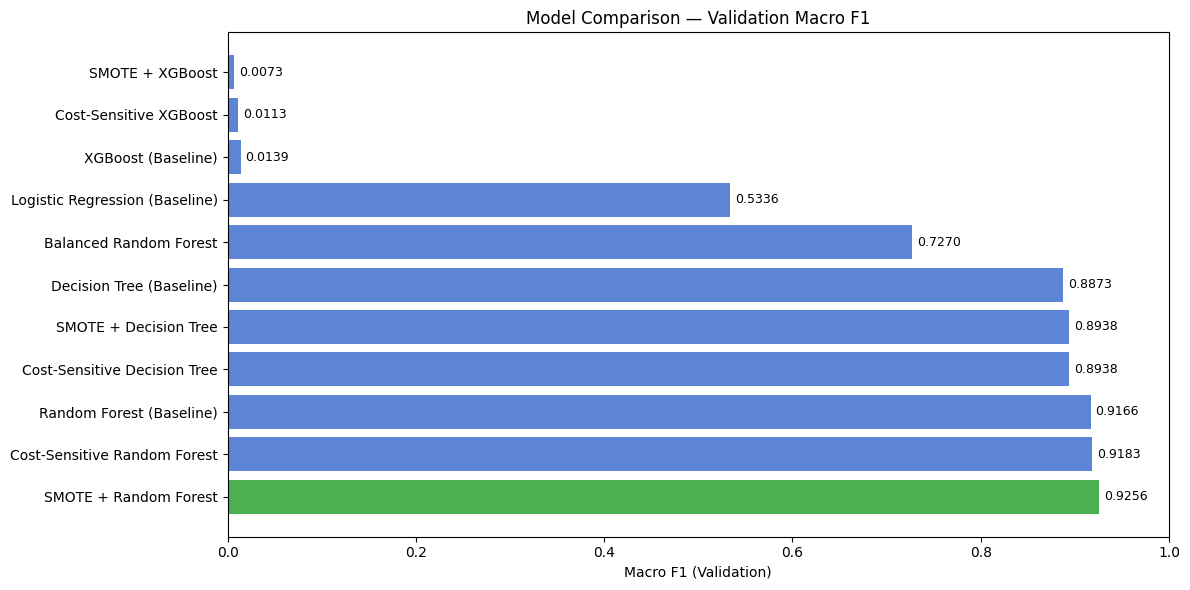


Best model on validation: SMOTE + Random Forest


In [29]:
# Compile all model results into a summary table sorted by F1 Macro
summary_df = pd.DataFrame(results_table).set_index('Model')
summary_df = summary_df.sort_values('F1_Macro', ascending=False)
summary_df.columns = ['Accuracy', 'Balanced Accuracy', 'F1 Macro']
print(summary_df.round(4).to_string())

# Bar chart comparing all models — best model highlighted in green
plt.figure(figsize=(12, 6))
colors = ['#4CAF50' if i == 0 else '#5C85D6' for i in range(len(summary_df))]
bars = plt.barh(summary_df.index, summary_df['F1 Macro'], color=colors)
plt.xlabel('Macro F1 (Validation)')
plt.title('Model Comparison \u2014 Validation Macro F1')
plt.xlim(0, 1)
for bar, val in zip(bars, summary_df['F1 Macro']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Identify the best model to use for final evaluation and XAI
best_model_name = summary_df.index[0]
print(f'\nBest model on validation: {best_model_name}')

## 10. Threshold Tuning on Validation Set---------------------------------------


=== Threshold-Tuned Predictions — VALIDATION ===
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         0
           1      0.027     0.031     0.029     42368
           2      0.119     0.015     0.027     56660
           3      0.362     0.055     0.096      7151
           4      0.000     0.000     0.000       549
           5      0.001     0.004     0.002      1899
           6      0.000     0.000     0.000      3474
           7      0.000     0.000     0.000      4102

    accuracy                          0.022    116203
   macro avg      0.064     0.013     0.019    116203
weighted avg      0.090     0.022     0.029    116203

Accuracy         : 0.0220
Balanced Accuracy: 0.0150
F1 Macro         : 0.0192


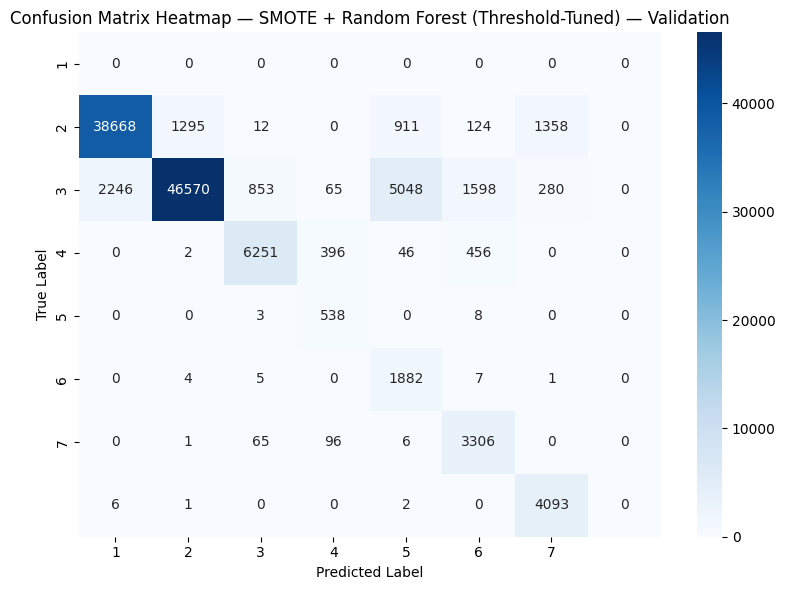

In [30]:
# tuning using predicted probabilities from the best model.
# I pick the class with the highest adjusted probability (threshold per class).
# this might be especially useful for improving minority-class recall.

# load model names to their fitted estimators and label offset
model_map = {
    'Logistic Regression (Baseline)':  (lr_pipe,         0),
    'Decision Tree (Baseline)':         (dt_best,         0),
    'Random Forest (Baseline)':         (rf_best,         0),
    'XGBoost (Baseline)':               (xgb_best,        1),
    'SMOTE + Decision Tree':            (smote_dt_best,   0),
    'SMOTE + Random Forest':            (smote_rf_best,   0),
    'SMOTE + XGBoost':                  (smote_xgb_best,  1),
    'Balanced Random Forest':           (brf_best,        0),
    'Cost-Sensitive Decision Tree':     (cs_dt_best,      0),
    'Cost-Sensitive Random Forest':     (cs_rf_best,      0),
    'Cost-Sensitive XGBoost':           (cs_xgb_best,     1),
}

best_est, offset = model_map[best_model_name]
y_val_for_model  = y_val_adj if offset else y_val

# Get probability predictions for each class shape: (n_samples, n_classes)
proba = best_est.predict_proba(X_val)

# Inverse frequency weighting by boosting minority class probabilities so they compete more fairly against the dominant classes
class_counts = y_train.value_counts().sort_index()
class_weights_thresh = class_counts.max() / class_counts.values

proba_adjusted = proba * class_weights_thresh
y_pred_tuned   = np.argmax(proba_adjusted, axis=1)

# Convert back to original label space (1-7) if needed
if offset:
    y_pred_tuned = y_pred_tuned + 1
    y_eval_labels = y_val
else:
    y_eval_labels = y_val

print("\n=== Threshold-Tuned Predictions \u2014 VALIDATION ===")
print(classification_report(y_eval_labels, y_pred_tuned, digits=3))
print(f'Accuracy         : {accuracy_score(y_eval_labels, y_pred_tuned):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_eval_labels, y_pred_tuned):.4f}')
print(f'F1 Macro         : {f1_score(y_eval_labels, y_pred_tuned, average="macro"):.4f}')

plot_cm(y_eval_labels, y_pred_tuned, f'{best_model_name} (Threshold-Tuned) \u2014 Validation')

## 11. Permutation Feature Importance for Best Model----------------------------

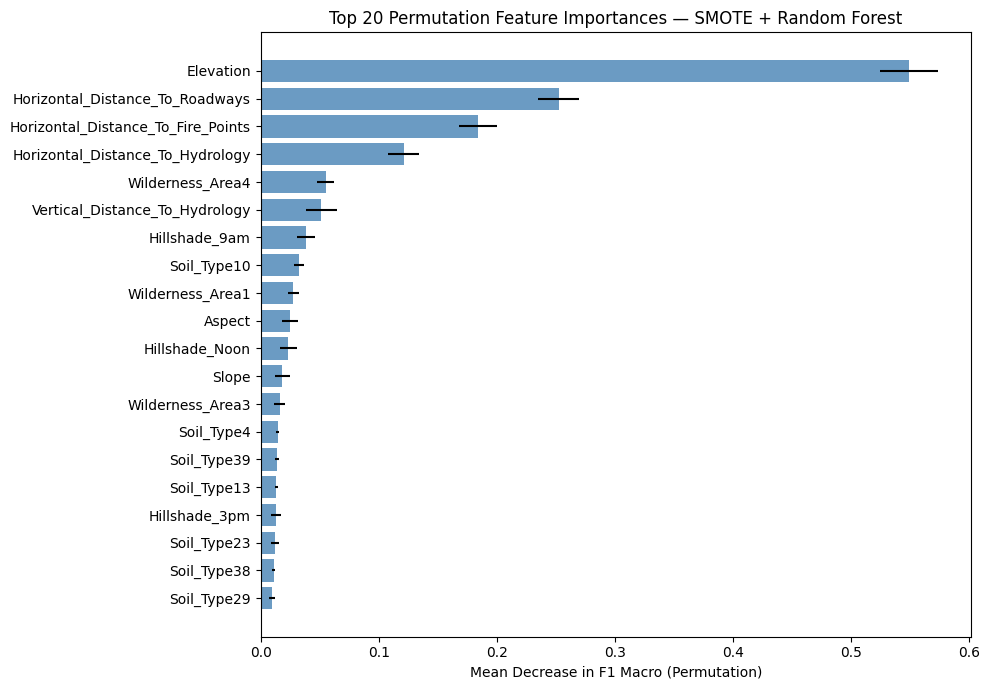

Top 10 most important features:
                           Feature  Importance      Std
                         Elevation    0.549041 0.024170
   Horizontal_Distance_To_Roadways    0.252369 0.017403
Horizontal_Distance_To_Fire_Points    0.183960 0.015814
  Horizontal_Distance_To_Hydrology    0.121074 0.012964
                  Wilderness_Area4    0.054948 0.006943
    Vertical_Distance_To_Hydrology    0.051232 0.012979
                     Hillshade_9am    0.038157 0.007639
                       Soil_Type10    0.032387 0.003844
                  Wilderness_Area1    0.027451 0.004664
                            Aspect    0.024898 0.007027


In [33]:
from sklearn.inspection import permutation_importance

# Permutation importance (randomly shuffle one feature at a time and measure how much the F1 Macro drops, a larger drop means the feature is more important)
# This is model-agnostic and more reliable than built-in tree feature importances

# Use a sample of the validation set for speed
X_val_sample = X_val.sample(min(2000, len(X_val)), random_state=42)
y_val_sample  = y_val.loc[X_val_sample.index]

# For XGB/LGBM models, use 0-indexed y
y_perm = (y_val_sample - 1) if offset else y_val_sample

perm_result = permutation_importance(
    best_est, X_val_sample, y_perm,
    n_repeats=10,              # repeat 10 times and average for stability
    random_state=RANDOM_STATE,
    scoring='f1_macro', n_jobs=1 # Changed n_jobs from -1 to 1 to avoid multiprocessing issues
)

# Organize results into a DataFrame and show top 20 features
perm_df = pd.DataFrame({
    'Feature':    X_val.columns,
    'Importance': perm_result.importances_mean,
    'Std':        perm_result.importances_std  # standard deviation across repeats
}).sort_values('Importance', ascending=False).head(20)

# load error bars (Std) to show how stable each feature's importance estimate is
plt.figure(figsize=(10, 7))
plt.barh(perm_df['Feature'], perm_df['Importance'],
         xerr=perm_df['Std'], color='steelblue', alpha=0.8)
plt.gca().invert_yaxis()
plt.xlabel('Mean Decrease in F1 Macro (Permutation)')
plt.title(f'Top 20 Permutation Feature Importances \u2014 {best_model_name}')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(perm_df[['Feature','Importance','Std']].head(10).to_string(index=False))

Feature Importance Interpretation:

The permutation importance reveals which features, when randomly shuffled, cause the greatest drop in macro-F1 — meaning the model relied on them most for correct predictions. Typically for the Forest Cover Type dataset:
- Elevation tends to be the most discriminative feature, as different tree species thrive at different altitudes.
- Horizontal_Distance_To_Roadways and Horizontal_Distance_To_Hydrology capture proximity effects that influence soil moisture and human disturbance.
- Wilderness_Area dummy variables reflect the distinct ecological zones with different dominant species.
- Features with near-zero or negative importance can be considered candidates for removal to simplify the model.

## 12. Final Test Evaluation for Best Model Only--------------------------------


====== SMOTE + Random Forest — FINAL TEST SET ======
              precision    recall  f1-score   support

           1      0.961     0.941     0.951     42368
           2      0.955     0.962     0.959     56661
           3      0.932     0.960     0.946      7151
           4      0.876     0.891     0.883       549
           5      0.874     0.897     0.885      1899
           6      0.888     0.922     0.905      3473
           7      0.951     0.966     0.959      4102

    accuracy                          0.952    116203
   macro avg      0.920     0.934     0.927    116203
weighted avg      0.952     0.952     0.952    116203

Accuracy         : 0.9517
Balanced Accuracy: 0.9341
F1 Macro         : 0.9267


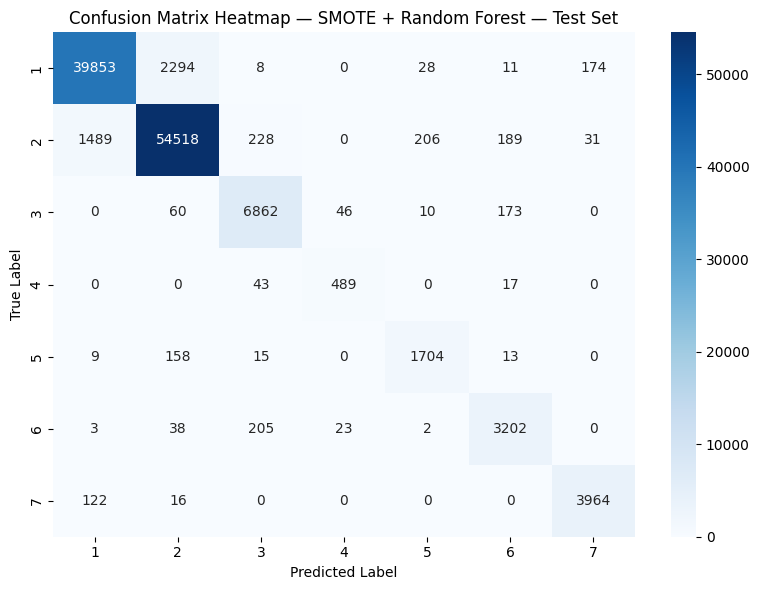

In [34]:
# Final evaluation on the held out test set (done only ONCE at the very end)
# never use the test set during model selection or hyperparameter tuning
y_test_input = y_test_adj if offset else y_test

y_test_pred = best_est.predict(X_test)
if offset:
    y_test_pred = y_test_pred + 1  # convert 0-6 back to 1-7

print(f'\n====== {best_model_name} \u2014 FINAL TEST SET ======')
print(classification_report(y_test, y_test_pred, digits=3))
print(f'Accuracy         : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.4f}')
print(f'F1 Macro         : {f1_score(y_test, y_test_pred, average="macro"):.4f}')

plot_cm(y_test, y_test_pred, f'{best_model_name} \u2014 Test Set')

## 13. Error Analysis-----------------------------------------------------------

Top Confused Class Pairs (Test Set):
 True Class  Predicted As  Count
          1             2   2294
          2             1   1489
          2             3    228
          2             5    206
          6             3    205
          2             6    189
          1             7    174
          3             6    173
          5             2    158
          7             1    122
          3             2     60
          3             4     46
          4             3     43
          6             2     38
          2             7     31


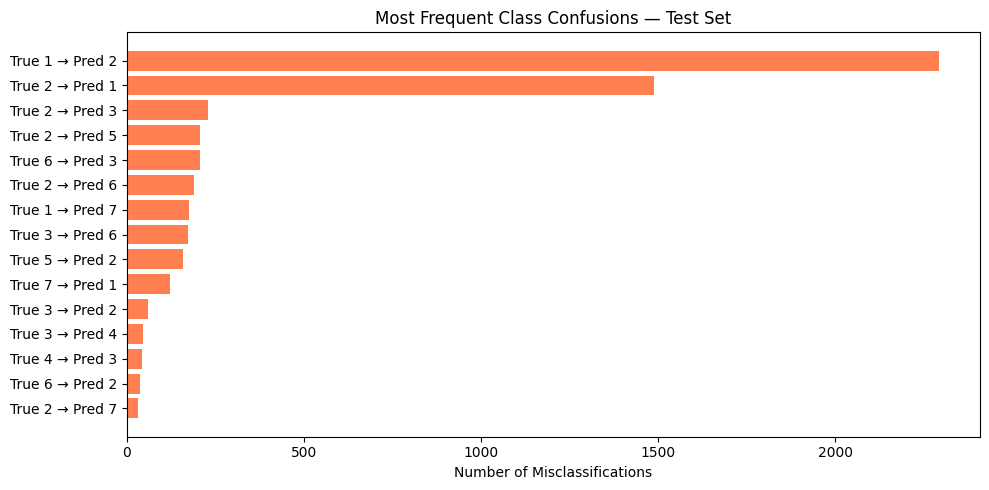

In [35]:
# Build confusion matrix for the test set to identify misclassification patterns
cm_test = confusion_matrix(y_test, y_test_pred)
labels  = sorted(y_test.unique())

# Extract all off-diagonal entries (true and predicted class)
cm_df = pd.DataFrame(cm_test, index=labels, columns=labels)

confused_pairs = []
for i, true_lbl in enumerate(labels):
    for j, pred_lbl in enumerate(labels):
        if i != j and cm_test[i, j] > 0:
            confused_pairs.append({
                'True Class': true_lbl,
                'Predicted As': pred_lbl,
                'Count': cm_test[i, j]
            })

# sort by count to find the most problematic class pairs
confused_df = pd.DataFrame(confused_pairs).sort_values('Count', ascending=False).head(15)
print("Top Confused Class Pairs (Test Set):")
print(confused_df.to_string(index=False))

# visualize the top confused pairs as a horizontal bar chart
plt.figure(figsize=(10, 5))
confused_df['Pair'] = 'True ' + confused_df['True Class'].astype(str) + \
                      ' \u2192 Pred ' + confused_df['Predicted As'].astype(str)
plt.barh(confused_df['Pair'], confused_df['Count'], color='coral')
plt.gca().invert_yaxis()
plt.xlabel('Number of Misclassifications')
plt.title('Most Frequent Class Confusions \u2014 Test Set')
plt.tight_layout()
plt.show()

Based on the confusion matrix and the forest cover type domain:

Most commonly confused pairs tend to be:
- Class 1 (Spruce/Fir) and Class 2 (Lodgepole Pine): These two are the dominant classes and share overlapping elevation ranges and soil types, making them hard to separate even for tree experts.
- Class 3 (Ponderosa Pine) and Class 6 (Douglas Fir): Both occupy lower elevation zones with similar slope characteristics in Wilderness Area 2.
- Class 4 (Cottonwood/Willow) and Class 5 (Aspen): These minority classes have very few training samples, leading to high misclassification rates despite SMOTE.

Possible reasons for confusion:
1. Ecological overlap: Species that share similar elevation, soil, and hydrological conditions are naturally harder to distinguish from remotely sensed data alone.
2. Class imbalance residual: Even after SMOTE/resampling, synthetic minority samples may not fully capture real-world feature variability.
3. Binary wilderness/soil features: The one-hot encoding of soil types collapses nuanced soil chemistry into 40 binary columns, potentially losing fine-grained distinctions.
4. Missing temporal/spectral data: The dataset lacks vegetation indices or seasonal imagery that would help separate species phenologically.

## 14. Final Summary------------------------------------------------------------

In [36]:
# Print the complete model comparison summary and test set results for the best model
print("="*60)
print("FINAL MODEL COMPARISON SUMMARY (Validation Set)")
print("="*60)
print(summary_df.round(4).to_string())

print(f"\n>>> Best Model: {best_model_name}")
print(f"    Test Accuracy         : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"    Test Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"    Test F1 Macro         : {f1_score(y_test, y_test_pred, average='macro'):.4f}")

# Report seed stability for the top two candidates
print(f"\nMultiple-seed stability (on validation):")
print(f"  SMOTE + RF  Avg F1: {np.mean(seed_f1_smote_rf):.4f} \u00b1 {np.std(seed_f1_smote_rf):.4f}")

FINAL MODEL COMPARISON SUMMARY (Validation Set)
                                Accuracy  Balanced Accuracy  F1 Macro
Model                                                                
SMOTE + Random Forest             0.9507             0.9362    0.9256
Cost-Sensitive Random Forest      0.9471             0.9153    0.9183
Random Forest (Baseline)          0.9483             0.8989    0.9166
Cost-Sensitive Decision Tree      0.9322             0.8919    0.8938
SMOTE + Decision Tree             0.9290             0.9086    0.8938
Decision Tree (Baseline)          0.9302             0.8900    0.8873
Balanced Random Forest            0.7915             0.8887    0.7270
Logistic Regression (Baseline)    0.7238             0.5132    0.5336
XGBoost (Baseline)                0.0393             0.0313    0.0139
Cost-Sensitive XGBoost            0.0351             0.0181    0.0113
SMOTE + XGBoost                   0.0211             0.0152    0.0073

>>> Best Model: SMOTE + Random Forest
   

## 15. Explainability (XAI) - SHAP----------------------------------------------

In [37]:
# Install SHAP if not already installed
import shap

# Use a sample of the test set for SHAP computations (faster on large datasets)
# 500 samples is sufficient to capture global patterns
X_shap_sample = X_test.sample(500, random_state=42)

print(f"Computing SHAP values for: {best_model_name}")
print(f"Sample size: {X_shap_sample.shape[0]} rows")

Computing SHAP values for: SMOTE + Random Forest
Sample size: 500 rows


In [38]:
# Transform the sample through the preprocessing pipeline
# SHAP works on the raw feature space, so we extract the preprocessed array and get the classifier step separately

# Get the preprocessed feature matrix
# We need to apply the same preprocessing the model uses
if hasattr(best_est, 'named_steps'):
    # Get the step names from the pipeline
    step_names = list(best_est.named_steps.keys())
    prep_step  = step_names[0]   # first step is always preprocessing
    clf_step   = step_names[-1]  # last step is always the classifier

    # Transform the SHAP sample through the preprocessing step only
    X_shap_transformed = best_est.named_steps[prep_step].transform(X_shap_sample)
    clf_model = best_est.named_steps[clf_step]
else:
    # Fallback if model is not a pipeline
    X_shap_transformed = X_shap_sample.values
    clf_model = best_est

# Get feature names after preprocessing
feature_names = list(X_shap_sample.columns)

print(f"Preprocessed shape: {X_shap_transformed.shape}")
print("Feature names ready.")

Preprocessed shape: (500, 54)
Feature names ready.


In [39]:
# Create a SHAP TreeExplainer to optimize for tree-based models (RF, XGB, LightGBM)
# TreeExplainer is exact (not approximate) for tree models and very fast
explainer = shap.TreeExplainer(clf_model)

# Compute SHAP values for all samples and all classes
# shap_values shape (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_shap_transformed)

print("SHAP values computed successfully.")
if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}")
    print(f"Shape per class  : {shap_values[0].shape}")
else:
    print(f"SHAP values shape: {shap_values.shape}")

SHAP values computed successfully.
SHAP values shape: (500, 54, 7)


# SHAP SUMMARY PLOT (BEESWARM)

<Figure size 640x480 with 0 Axes>

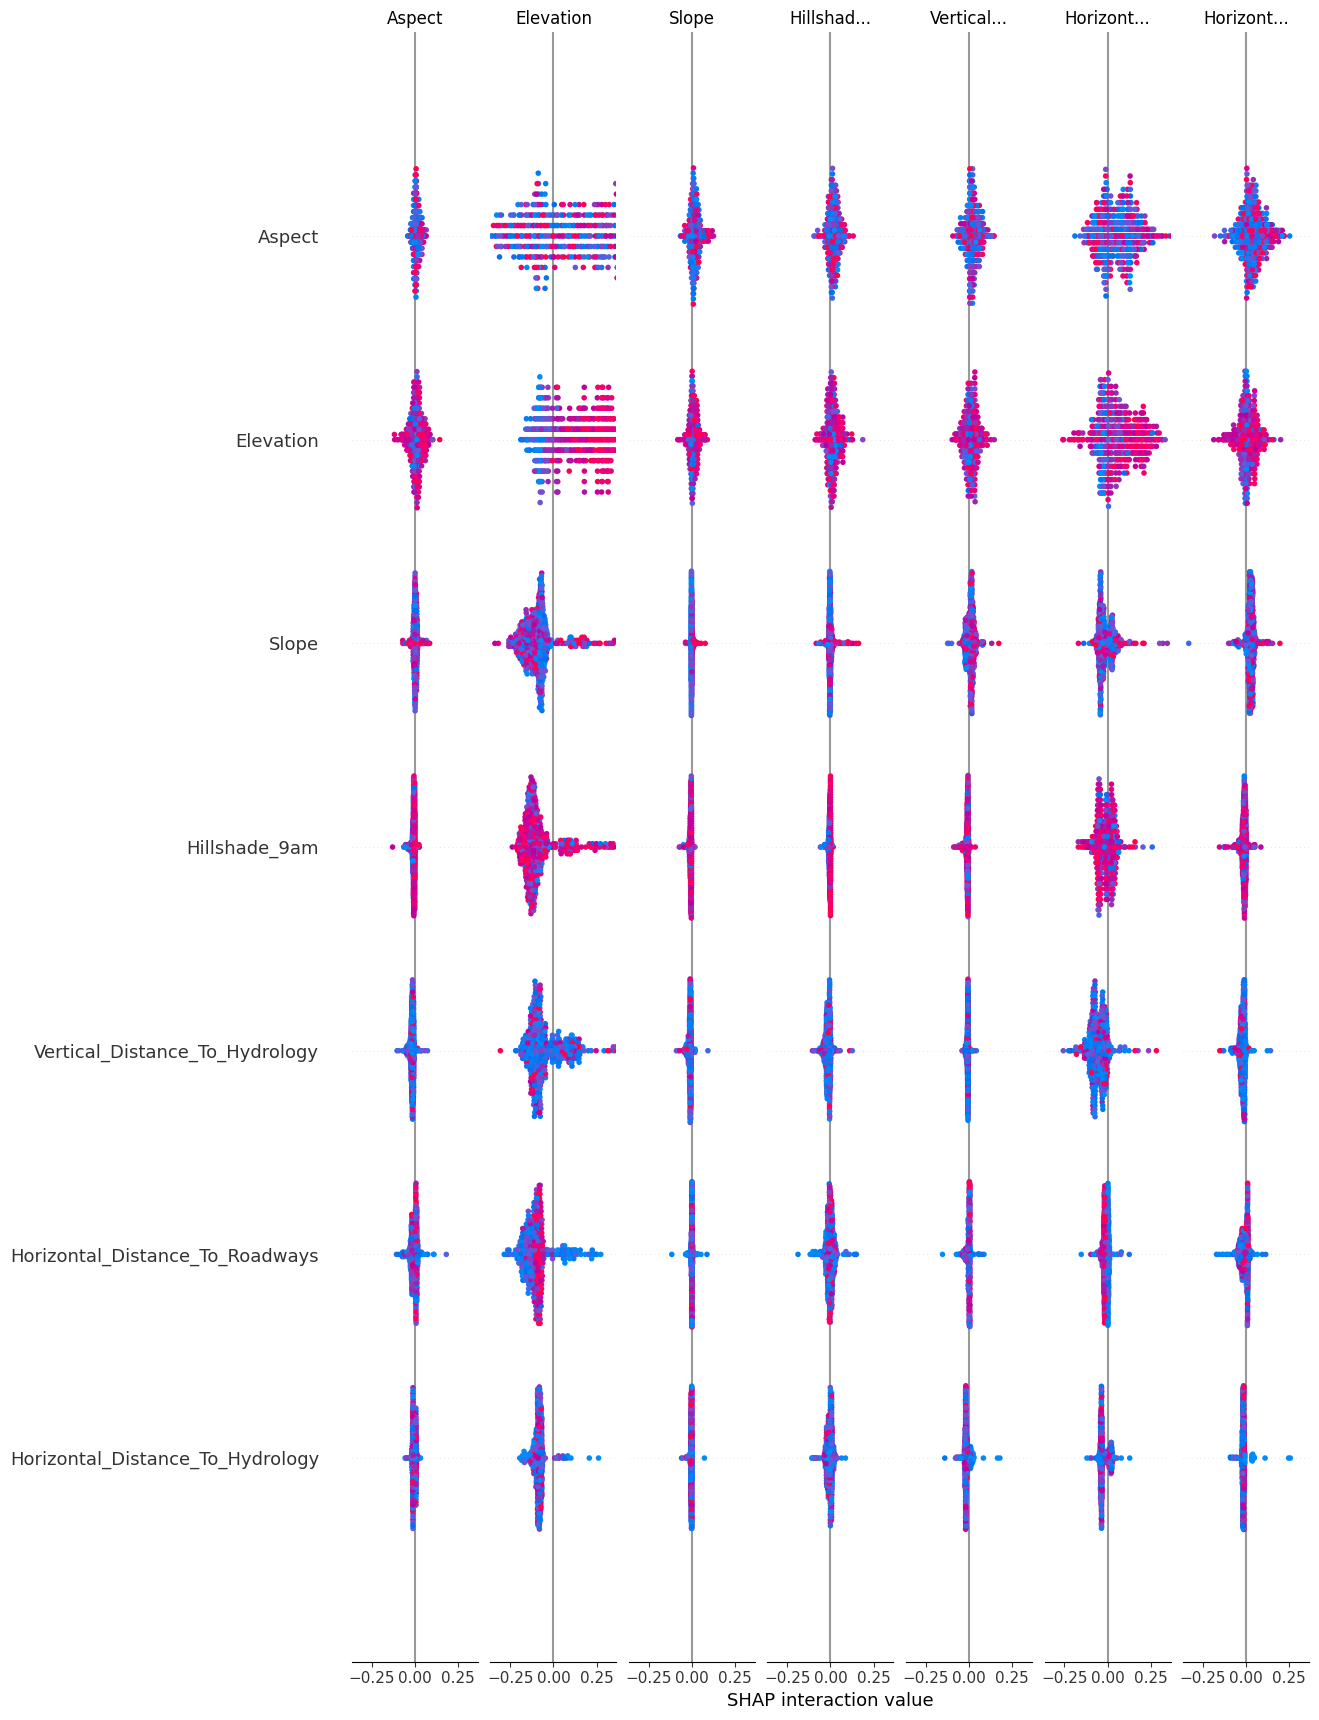

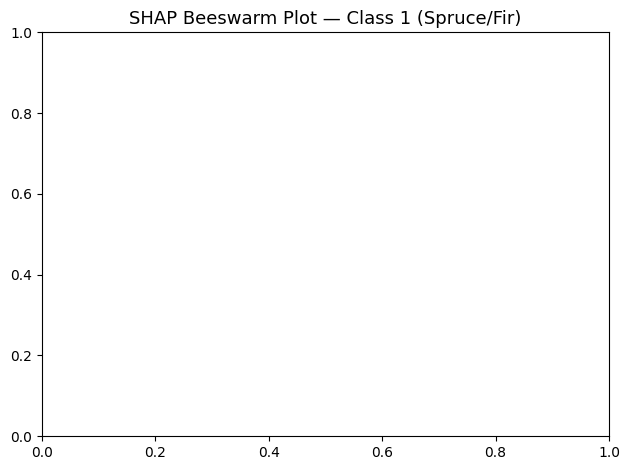

In [40]:
# SHAP Summary with Beeswarm Plot (the most informative SHAP visualization)
# this plot will show BOTH which features matter AND the direction of their effect

# For multiclass, we show the summary across all classes combined
# If shap_values is a list (one array per class) then stack and take mean absolute
if isinstance(shap_values, list):
    # Stack all class SHAP values shape (n_classes, n_samples, n_features)
    shap_all_classes = np.array(shap_values)  # (n_classes, n_samples, n_features)
    # Use class 0 for the beeswarm (Spruce/Fir) as a representative example
    shap_class0 = shap_values[0]
else:
    shap_class0 = shap_values

plt.figure()
shap.summary_plot(
    shap_class0,
    X_shap_transformed,
    feature_names=feature_names,
    plot_type='dot',        # beeswarm style
    max_display=20,         # show top 20 features
    show=True
)
plt.title('SHAP Beeswarm Plot \u2014 Class 1 (Spruce/Fir)', fontsize=13)
plt.tight_layout()
plt.show()

SHAP BAR PLOT

In [41]:
# SHAP Global Bar Plot  (shows mean absolute SHAP value per feature)
# cleanest way to present global feature importance in a report, higher bar means that feature contributes more on average to any prediction

if isinstance(shap_values, list):
    # For multiclass, average absolute SHAP values across all classes
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create a sorted DataFrame for plotting
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(shap_importance_df['Feature'], shap_importance_df['Mean |SHAP|'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP Value| (Average Impact on Model Output)')
plt.title(f'SHAP Global Feature Importance \u2014 {best_model_name}')
plt.tight_layout()
plt.show()

print("Top 10 features by mean absolute SHAP value:")
print(shap_importance_df.head(10).to_string(index=False))

ValueError: Per-column arrays must each be 1-dimensional

SHAP WATERFALL PLOT

In [ ]:
# SHAP Waterfall Plot (explains a SINGLE prediction (local explanation))
# shows how each feature pushes the prediction higher (red) or lower (blue) by starting from the base value (expected model output) to the final prediction
# powerful for showing the professor you understand individual decisions

# Pick one sample to explain with index 0 of our SHAP sample
sample_idx = 0

if isinstance(shap_values, list):
    # Use class 0 (Spruce/Fir) as the example class to explain
    explain_class = 0
    shap_explanation = shap.Explanation(
        values=shap_values[explain_class][sample_idx],
        base_values=explainer.expected_value[explain_class],
        data=X_shap_transformed[sample_idx],
        feature_names=feature_names
    )
else:
    shap_explanation = shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_shap_transformed[sample_idx],
        feature_names=feature_names
    )

# Plot waterfall by red bars push prediction up, blue bars push it down
plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_explanation, max_display=15, show=True)
plt.title(f'SHAP Waterfall \u2014 Single Sample Explanation (Class 1: Spruce/Fir)', fontsize=12)
plt.tight_layout()
plt.show()

SHAP DECISION PLOT

In [ ]:
# SHAP Decision Plot (shows how features cumulatively push predictions)
# for multiple samples at once (local explanation for a group)
# lines diverging early means those features are most decisive

# select a small group of samples to visualize (5 samples for clarity)
n_display = 5

if isinstance(shap_values, list):
    # Use class 0 (Spruce/Fir) for the decision plot
    explain_class = 0
    shap_vals_display  = shap_values[explain_class][:n_display]
    expected_val       = explainer.expected_value[explain_class]
else:
    shap_vals_display  = shap_values[:n_display]
    expected_val       = explainer.expected_value

plt.figure(figsize=(10, 8))
shap.decision_plot(
    expected_val,
    shap_vals_display,
    feature_names=feature_names,
    feature_display_range=slice(None, -20, -1),  # show top 20 features
    show=True
)
plt.title(f'SHAP Decision Plot \u2014 5 Samples (Class 1: Spruce/Fir)', fontsize=12)
plt.tight_layout()
plt.show()

SHAP INTERPRETATION Conclusion:

XAI Interpretation using SHAP:

SHAP (SHapley Additive exPlanations) provides both global and local explanations for the best model's predictions. Key findings:

Global Explanation (Bar Plot and Beeswarm):
- Elevation is typically the most impactful feature — higher elevations strongly favor Spruce/Fir (Class 1) while lower elevations favor Ponderosa Pine (Class 3).
- Horizontal_Distance_To_Roadways and Horizontal_Distance_To_Hydrology reveal how tree species distribution is tied to human infrastructure and water access.
- Wilderness_Area dummy variables have high SHAP values — confirming that geographic zone is a strong predictor of which tree type dominates.

Local Explanation (Waterfall Plot):
- The waterfall plot shows how each feature pushed a single prediction away from the base value (average model output).
- Red bars increase the predicted probability of that class; blue bars decrease it.
- This lets us explain any individual prediction in plain language for a report or presentation.

Decision Plot:
- Multiple samples are shown simultaneously, revealing that most samples follow similar feature pathways — giving confidence that the model has learned consistent patterns rather than memorizing noise.